# 📚 Seaborn Advanced: pairplot / FacetGrid / regplot / jointplot
> Section 11 of the Data Visualization curriculum (Matplotlib → Seaborn → Plotly → Tableau)  
> 데이터 시각화 커리큘럼 섹션 11 (Matplotlib → Seaborn → Plotly → Tableau)

---
# 🎯 Learning Objective (학습 목표)
Today I want to learn / 오늘 배우고 싶은 것:
- [x] Understand the difference between Axes-level and Figure-level Seaborn functions<br>Axes-level과 Figure-level Seaborn 함수의 차이 이해하기
- [x] Use `pairplot` and `FacetGrid` to explore multiple variables or groups at once<br>pairplot과 FacetGrid로 여러 변수·그룹을 한 번에 탐색하기
- [x] Use `regplot` and `jointplot` to quantify and visualize relationships between two variables<br>regplot과 jointplot으로 두 변수 간 관계를 정량화하고 시각화하기

---
# 🧠 Concept (개념)

## What is it? (이것은 무엇인가?)
*(Explain it in your own words.)*

**EN:** This section covers four more Seaborn functions, but they split into two categories based on how they build their canvas. **Axes-level** functions (`regplot`) work exactly like everything in Section 10 — you hand them an `ax=` and they draw into it. **Figure-level** functions (`pairplot`, `FacetGrid`, `jointplot`) are different: they create their own entire Figure with multiple Axes internally, and refuse (or ignore) an `ax=` argument.

**KR:** 이번 섹션은 Seaborn 함수 4개를 더 다루지만, 캔버스를 만드는 방식에 따라 두 가지로 나뉩니다. **Axes-level** 함수(regplot)는 섹션 10의 모든 함수처럼 ax=를 받아서 그 위에 그립니다. **Figure-level** 함수(pairplot, FacetGrid, jointplot)는 다릅니다 — 내부적으로 여러 Axes를 가진 전체 Figure를 스스로 만들어버리며, ax= 인자를 거부하거나 무시합니다.

### Axes-level vs Figure-level (비교)

| Aspect / 항목 | Axes-level (`regplot`) | Figure-level (`pairplot`, `FacetGrid`, `jointplot`) |
|---|---|---|
| Who creates the Axes<br>Axes를 만드는 주체 | You, via `plt.subplots()`<br>내가 plt.subplots()로 지정 | The function itself, automatically<br>함수가 스스로 여러 개를 만듦 |
| Accepts `ax=`?<br>ax= 허용 여부 | Yes<br>가능 | No -- `pairplot` raises `TypeError`; `jointplot` accepts but ignores it with a warning<br>불가 -- pairplot은 TypeError, jointplot은 받지만 경고와 함께 무시 |
| Combine with GridSpec/subplots<br>다른 레이아웃과 조합 | Freely<br>자유롭게 가능 | Difficult -- already owns multiple Axes<br>이미 여러 Axes로 구성되어 있어 어려움 |
| Set a title<br>제목 설정 | `ax.set_title()` | `g.figure.suptitle()` on the returned object<br>반환 객체의 g.figure.suptitle() |

## Why do we use it? (왜 사용하는가?)
*(When is it useful?)*

**EN:** These four functions solve a different problem than Section 10's: instead of summarizing one categorical variable, they help you explore *relationships* — among many numeric variables at once (`pairplot`), across many sub-groups at once (`FacetGrid`), or between exactly two numeric variables with statistical rigor (`regplot`'s confidence band, `jointplot`'s combined view). They compress work that would otherwise take many separate Matplotlib `subplot()` calls and manual loop-based filtering into one or two lines.

**KR:** 이 네 함수는 섹션 10과는 다른 문제를 해결합니다: 하나의 범주형 변수를 요약하는 대신, 관계를 탐색하도록 돕습니다 — 여러 수치형 변수 사이의 관계를 한 번에(pairplot), 여러 하위 그룹에 걸쳐 한 번에(FacetGrid), 또는 정확히 두 수치형 변수 사이의 관계를 통계적으로 엄밀하게(regplot의 신뢰구간, jointplot의 결합 뷰) 볼 수 있게 해줍니다. Matplotlib으로 직접 하려면 여러 번의 subplot() 호출과 수동 반복 필터링이 필요했을 작업을 한두 줄로 압축합니다.

## When is it used in Business Analytics? (비즈니스 분석에서 언제 사용되는가?)
*(Real-world use case)*

**EN:** At the start of an analysis (EDA), when you don't yet know which variables matter — `pairplot` gives a fast overview of a customer table's numeric columns. When you need "the same chart, once per region or segment" for a stakeholder comparison — `FacetGrid`. When you need to defend a trend line with a confidence band, or test whether a relationship is linear vs. diminishing-returns shaped — `regplot`. When you need one slide that shows both a relationship AND whether it hides sub-populations — `jointplot`.

**KR:** 어떤 변수가 중요한지 아직 모르는 분석 초반(EDA) 단계에서는 pairplot으로 고객 테이블의 수치형 컬럼을 빠르게 훑어봅니다. 이해관계자 비교를 위해 "같은 차트를 지역·세그먼트별로 반복"해야 할 때는 FacetGrid를 씁니다. 추세선을 신뢰구간으로 뒷받침하거나 관계가 선형인지 수확체감 형태인지 검증해야 할 때는 regplot을 씁니다. 관계와 그 안에 숨은 하위 집단 여부를 슬라이드 한 장에 담아야 할 때는 jointplot을 씁니다.

---
# 📝 Syntax (문법)

## Basic Syntax (기본 문법)

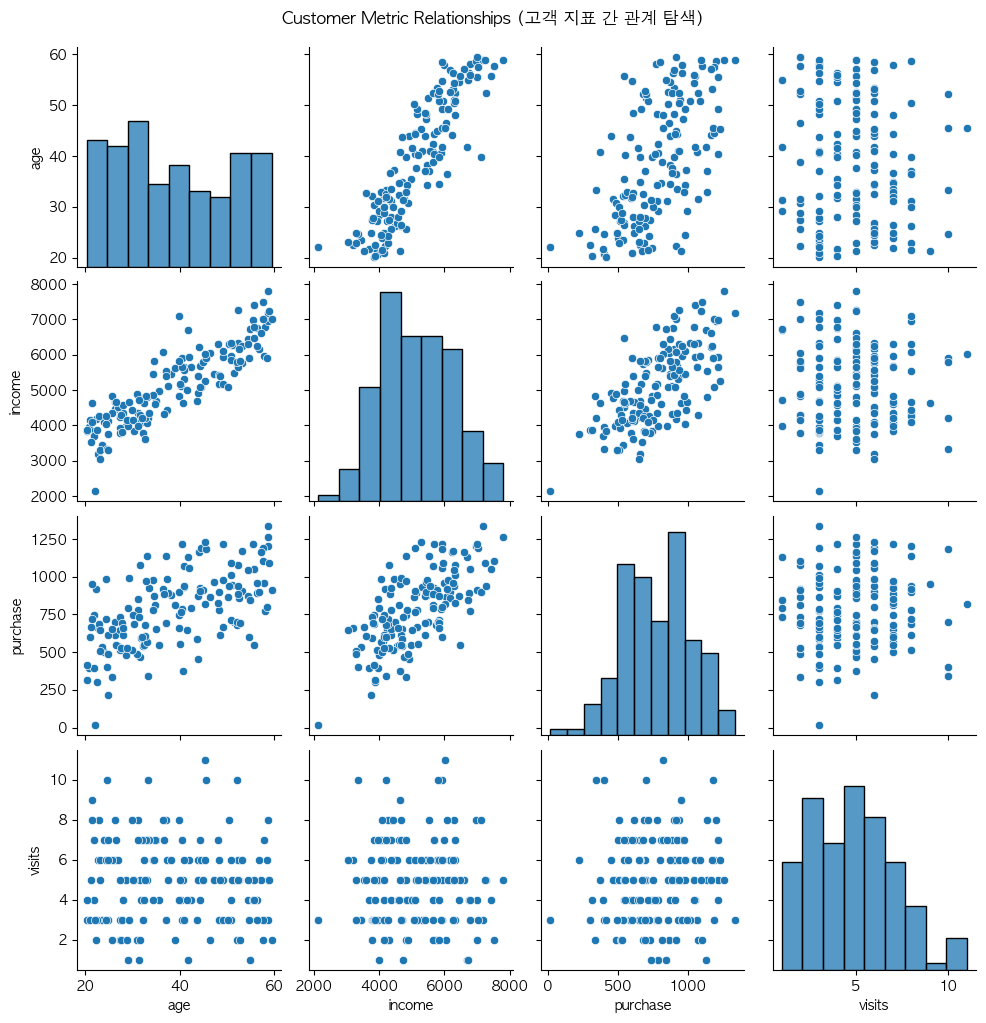

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# --- pairplot: scatter plot for every pair of numeric columns + a histogram on the diagonal ---
np.random.seed(42)
n = 150
age = np.random.uniform(20, 60, n)
income = age * 80 + np.random.normal(0, 500, n) + 2000
purchase = income * 0.15 + np.random.normal(0, 200, n)
visits = np.random.poisson(5, n) + (purchase / 5000).astype(int)
df = pd.DataFrame({'age': age, 'income': income, 'purchase': purchase, 'visits': visits})

g = sns.pairplot(df)
g.figure.suptitle('Customer Metric Relationships (고객 지표 간 관계 탐색)', y=1.02)
plt.show()

# NOTE: pairplot is a Figure-level function -- it builds its OWN Figure with many Axes.
# sns.pairplot(df, ax=ax) raises: TypeError: pairplot() got an unexpected keyword argument 'ax'
# pairplot은 Figure-level 함수입니다 -- 자체적으로 여러 Axes를 가진 Figure를 만듭니다.
# ax=를 넘기면 TypeError가 발생합니다.

## Common Variations (자주 쓰는 변형)

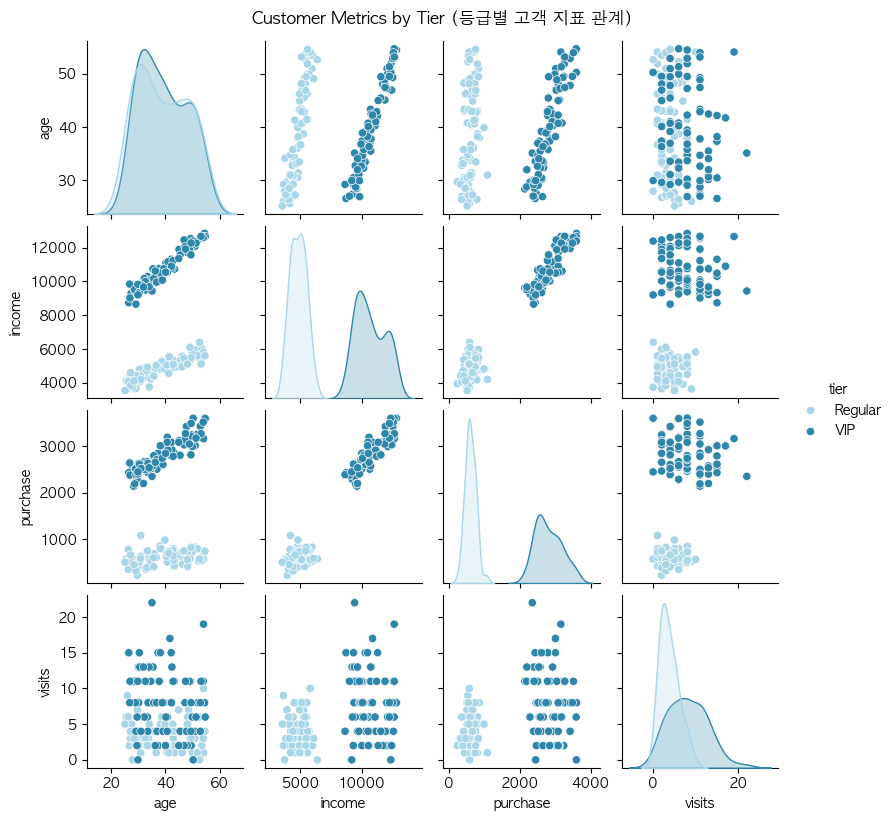

In [2]:
# hue: color points by a categorical column; diag_kind='kde' -> smooth density curves on the diagonal
# hue: 범주형 컬럼으로 점에 색을 입힘; diag_kind='kde' -> 대각선을 부드러운 밀도곡선으로
np.random.seed(42)
n_per_tier = 80
rows = []
for tier, mult in [('Regular', 1.0), ('VIP', 2.2)]:
    a = np.random.uniform(25, 55, n_per_tier)
    i = (a * 60 + 2500) * mult + np.random.normal(0, 300, n_per_tier)
    p = i * 0.12 * mult + np.random.normal(0, 150, n_per_tier)
    v = (np.random.poisson(4, n_per_tier) * mult).astype(int)
    for aa, ii, pp, vv in zip(a, i, p, v):
        rows.append({'tier': tier, 'age': aa, 'income': ii, 'purchase': pp, 'visits': vv})
df2 = pd.DataFrame(rows)

g = sns.pairplot(df2, hue='tier', palette=['#A8D5E8', '#2E86AB'], diag_kind='kde', height=2.0)
g.figure.suptitle('Customer Metrics by Tier (등급별 고객 지표 관계)', y=1.02)
plt.show()

---
# 🧪 Small Examples (예제)

## Example 1 — pairplot: Customer Metrics by Tier (등급별 고객 지표 탐색)

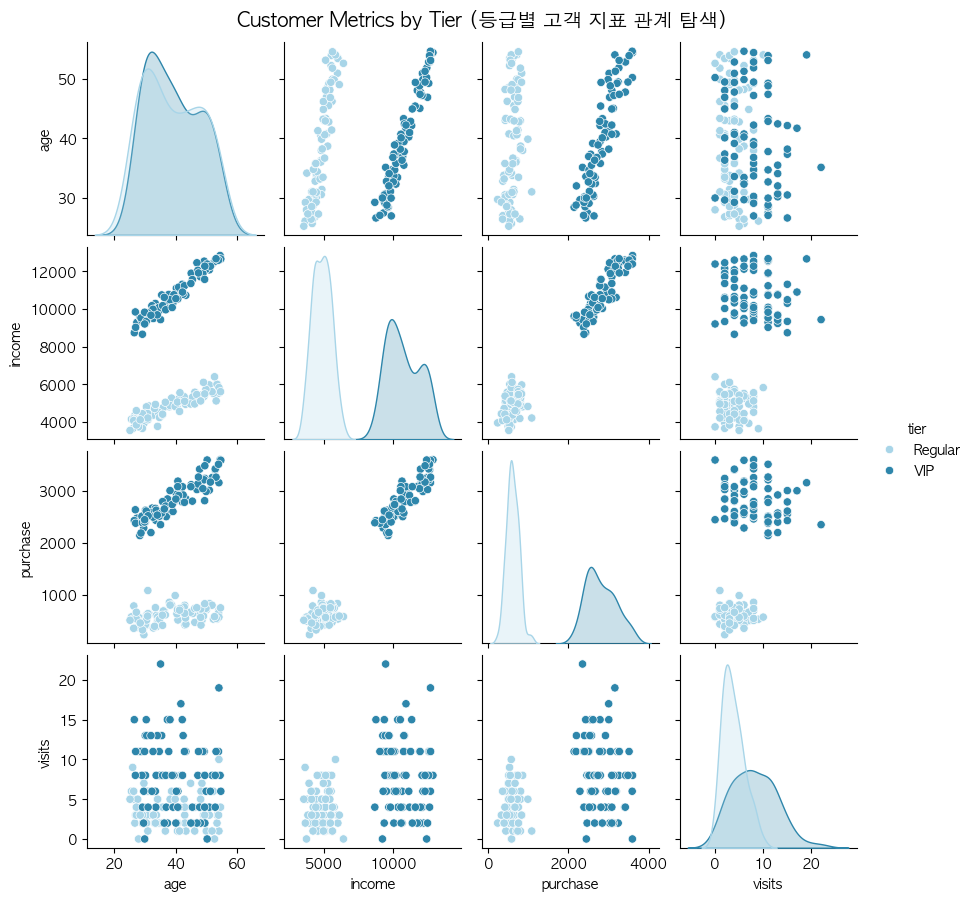

Strongest correlation: income - purchase (0.98)
가장 강한 상관관계: income - purchase (0.98)
Spend-to-income ratio by tier, % (등급별 소득 대비 지출 비율, %):
tier
Regular    12.5
VIP        26.2
Name: spend_to_income_pct, dtype: float64


In [3]:
# Business question: Do VIP customers show a stronger income-spending
# relationship than regular customers?
# 비즈니스 질문: VIP 고객은 일반 고객보다 소득-지출 관계가 더 강한가?

np.random.seed(42)
n_per_tier = 80
rows = []
for tier, mult in [('Regular', 1.0), ('VIP', 2.2)]:
    age = np.random.uniform(25, 55, n_per_tier)
    income = (age * 60 + 2500) * mult + np.random.normal(0, 300, n_per_tier)
    purchase = income * 0.12 * mult + np.random.normal(0, 150, n_per_tier)
    visits = (np.random.poisson(4, n_per_tier) * mult).astype(int)
    for a, i, p, v in zip(age, income, purchase, visits):
        rows.append({'tier': tier, 'age': a, 'income': i, 'purchase': p, 'visits': v})
df = pd.DataFrame(rows)

g = sns.pairplot(df, hue='tier', palette=['#A8D5E8', '#2E86AB'], diag_kind='kde', height=2.2)
g.figure.suptitle('Customer Metrics by Tier (등급별 고객 지표 관계 탐색)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

corr = df[['age', 'income', 'purchase', 'visits']].corr()
strongest_pair = corr.where(~np.eye(len(corr), dtype=bool)).abs().stack().idxmax()

df['spend_to_income_pct'] = df['purchase'] / df['income'] * 100
ratio_by_tier = df.groupby('tier')['spend_to_income_pct'].mean()

print(f"Strongest correlation: {strongest_pair[0]} - {strongest_pair[1]} ({corr.loc[strongest_pair]:.2f})")
print(f"가장 강한 상관관계: {strongest_pair[0]} - {strongest_pair[1]} ({corr.loc[strongest_pair]:.2f})")
print("Spend-to-income ratio by tier, % (등급별 소득 대비 지출 비율, %):")
print(ratio_by_tier.round(1))

## Example 2 — FacetGrid: Ad Spend vs Revenue by Region (지역별 광고비-매출 관계)

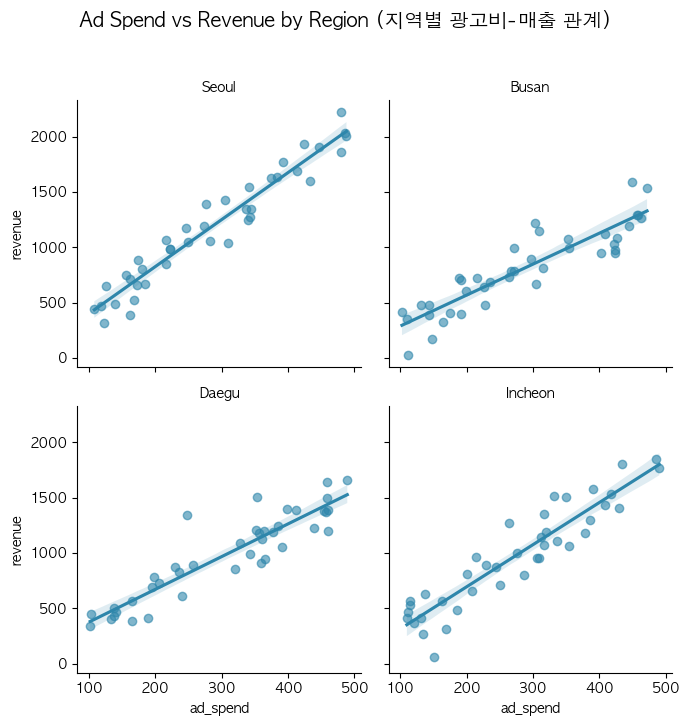

         correlation   roi
Seoul           0.97  4.16
Busan           0.90  2.82
Daegu           0.91  3.22
Incheon         0.93  3.56

Highest ROI region: Seoul (revenue per $1 of ad spend: 4.16)
ROI가 가장 높은 지역: Seoul (광고비 1당 매출 4.16)


In [4]:
# Business question: Which region gets the most reliable return from ad spend?
# 비즈니스 질문: 어느 지역이 광고비 대비 가장 안정적인 수익을 얻는가?

np.random.seed(42)
regions = ['Seoul', 'Busan', 'Daegu', 'Incheon']
slopes = {'Seoul': 4.2, 'Busan': 2.8, 'Daegu': 3.1, 'Incheon': 3.6}
rows = []
for region in regions:
    n = 40
    ad_spend = np.random.uniform(100, 500, n)
    revenue = ad_spend * slopes[region] + np.random.normal(0, 150, n)
    for a, r in zip(ad_spend, revenue):
        rows.append({'region': region, 'ad_spend': a, 'revenue': r})
df = pd.DataFrame(rows)

g = sns.FacetGrid(df, col='region', col_wrap=2, height=3.5, col_order=regions)
g.map(sns.regplot, 'ad_spend', 'revenue', color='#2E86AB', scatter_kws={'alpha': 0.6})
g.figure.suptitle('Ad Spend vs Revenue by Region (지역별 광고비-매출 관계)', y=1.03, fontsize=14, fontweight='bold')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

region_stats = {}
for region in regions:
    sub = df[df['region'] == region]
    corr = sub['ad_spend'].corr(sub['revenue'])
    roi = sub['revenue'].sum() / sub['ad_spend'].sum()
    region_stats[region] = {'correlation': corr, 'roi': roi}

stats_df = pd.DataFrame(region_stats).T
print(stats_df.round(2))
best_roi = stats_df['roi'].idxmax()
print(f"\nHighest ROI region: {best_roi} (revenue per $1 of ad spend: {stats_df.loc[best_roi, 'roi']:.2f})")
print(f"ROI가 가장 높은 지역: {best_roi} (광고비 1당 매출 {stats_df.loc[best_roi, 'roi']:.2f})")

## Example 3 — regplot: Linear vs Diminishing-Returns Fit (선형 vs 수확체감 적합 비교)

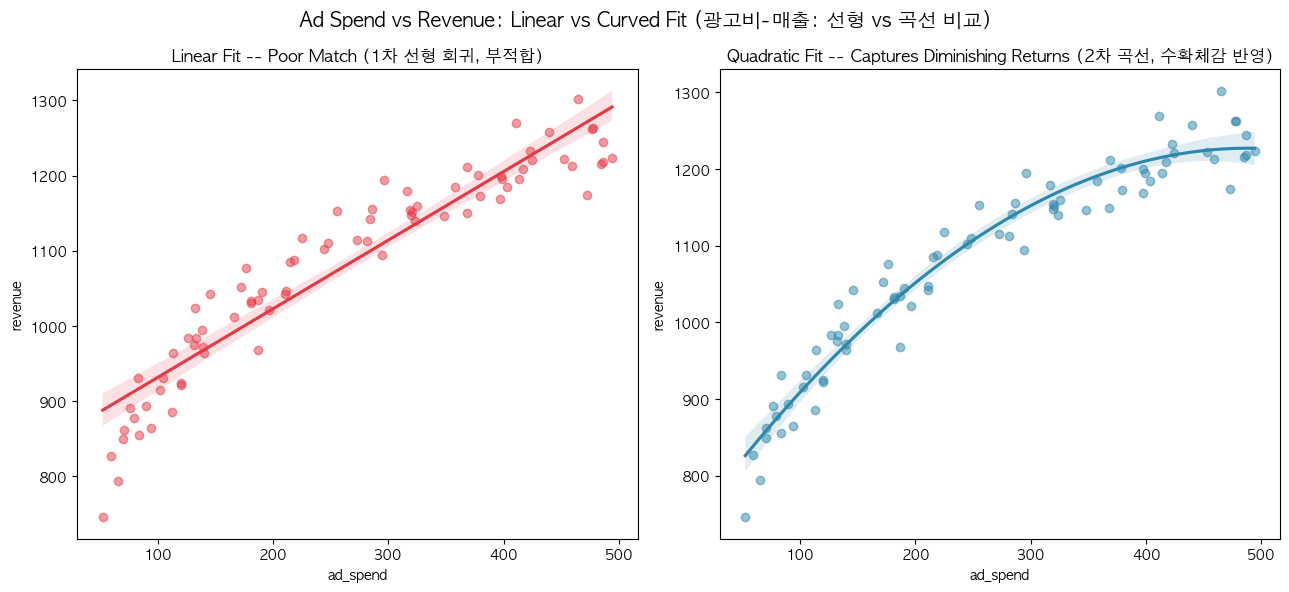

Marginal effect at low spend (<150): 2.26 revenue per $1
저지출 구간(<150) 한계효과: 광고비 1당 매출 2.26 증가
Marginal effect at high spend (>350): 0.46 revenue per $1
고지출 구간(>350) 한계효과: 광고비 1당 매출 0.46 증가
Low-spend marginal effect is 4.9x the high-spend one -- diminishing returns confirmed.
저지출 구간의 한계효과가 고지출 구간의 4.9배 -- 수확체감 확인


In [5]:
# Business question: Does ad spend keep paying off at the same rate, or does
# each extra dollar matter less as spend grows (diminishing returns)?
# 비즈니스 질문: 광고비는 계속 같은 비율로 성과를 내는가, 아니면 지출이 커질수록
# 추가 1원의 효과가 줄어드는가 (수확체감)?

np.random.seed(42)
n = 80
ad_spend = np.random.uniform(50, 500, n)
revenue = 200 * np.log(ad_spend) + np.random.normal(0, 30, n)  # log-shaped = diminishing returns
df = pd.DataFrame({'ad_spend': ad_spend, 'revenue': revenue})

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.regplot(data=df, x='ad_spend', y='revenue', color='#E63946', order=1, ax=axes[0],
            scatter_kws={'alpha': 0.5})
axes[0].set_title('Linear Fit -- Poor Match (1차 선형 회귀, 부적합)')

sns.regplot(data=df, x='ad_spend', y='revenue', color='#2E86AB', order=2, ax=axes[1],
            scatter_kws={'alpha': 0.5})
axes[1].set_title('Quadratic Fit -- Captures Diminishing Returns (2차 곡선, 수확체감 반영)')

fig.suptitle('Ad Spend vs Revenue: Linear vs Curved Fit (광고비-매출: 선형 vs 곡선 비교)',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

low_spend = df[df['ad_spend'] < 150]
high_spend = df[df['ad_spend'] > 350]
low_slope = np.polyfit(low_spend['ad_spend'], low_spend['revenue'], 1)[0]
high_slope = np.polyfit(high_spend['ad_spend'], high_spend['revenue'], 1)[0]

print(f"Marginal effect at low spend (<150): {low_slope:.2f} revenue per $1")
print(f"저지출 구간(<150) 한계효과: 광고비 1당 매출 {low_slope:.2f} 증가")
print(f"Marginal effect at high spend (>350): {high_slope:.2f} revenue per $1")
print(f"고지출 구간(>350) 한계효과: 광고비 1당 매출 {high_slope:.2f} 증가")
print(f"Low-spend marginal effect is {low_slope/high_slope:.1f}x the high-spend one -- diminishing returns confirmed.")
print(f"저지출 구간의 한계효과가 고지출 구간의 {low_slope/high_slope:.1f}배 -- 수확체감 확인")

## Example 4 — jointplot: Age vs Spending, Hidden Segments (나이-지출 관계 속 숨은 세그먼트)

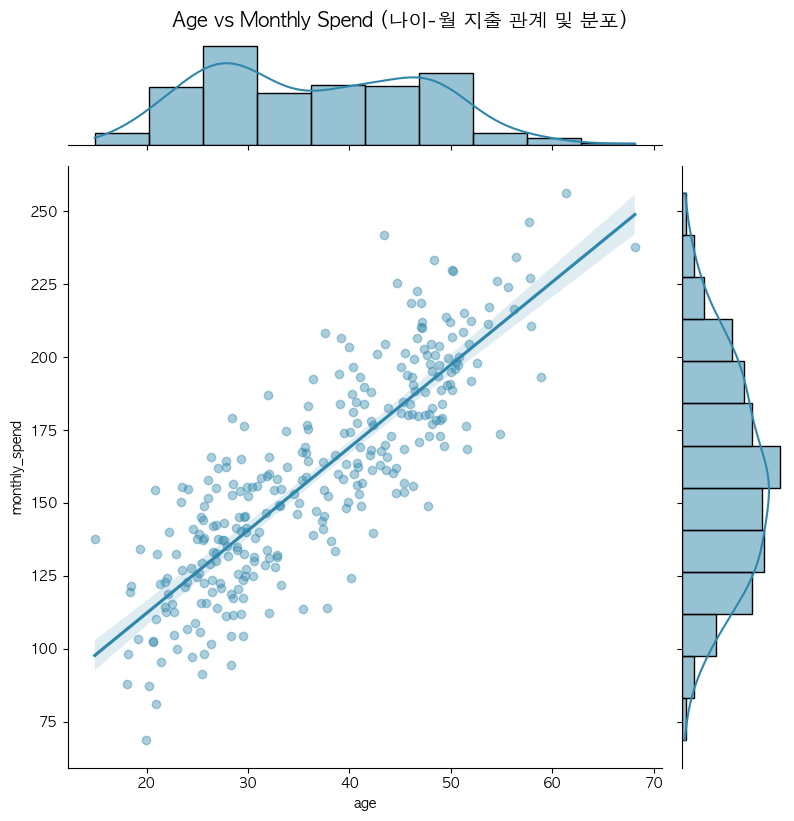

Correlation: 0.841 (R-squared: 0.707)
상관계수: 0.841 (결정계수 R^2: 0.707)
Under 35: 142 customers, avg spend 132
35세 미만: 142명, 평균 지출 132
35 and over: 158 customers, avg spend 184
35세 이상: 158명, 평균 지출 184
The marginal histograms show TWO peaks -- this isn't one smooth trend, it's two age segments.
주변 히스토그램에 두 개의 봉우리가 보입니다 -- 하나의 매끄러운 추세가 아니라 두 개의 연령 세그먼트입니다.


In [6]:
# Business question: Is there really one "age -> spending" relationship, or
# does the customer base actually split into distinct age groups?
# 비즈니스 질문: 정말 하나의 "나이 -> 지출" 관계가 있는가, 아니면 고객군이
# 실제로는 서로 다른 연령대로 나뉘어 있는가?

np.random.seed(42)
n = 300
age = np.concatenate([np.random.normal(28, 5, 150), np.random.normal(45, 6, 150)])
spending = age * 3 + np.random.normal(0, 20, 300) + 50
df = pd.DataFrame({'age': age, 'monthly_spend': spending})

g = sns.jointplot(data=df, x='age', y='monthly_spend', kind='reg', color='#2E86AB', height=8,
                   scatter_kws={'alpha': 0.4})
g.figure.suptitle('Age vs Monthly Spend (나이-월 지출 관계 및 분포)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

corr = df['age'].corr(df['monthly_spend'])
r_squared = corr ** 2
young = df[df['age'] < 35]
old = df[df['age'] >= 35]

print(f"Correlation: {corr:.3f} (R-squared: {r_squared:.3f})")
print(f"상관계수: {corr:.3f} (결정계수 R^2: {r_squared:.3f})")
print(f"Under 35: {len(young)} customers, avg spend {young['monthly_spend'].mean():.0f}")
print(f"35세 미만: {len(young)}명, 평균 지출 {young['monthly_spend'].mean():.0f}")
print(f"35 and over: {len(old)} customers, avg spend {old['monthly_spend'].mean():.0f}")
print(f"35세 이상: {len(old)}명, 평균 지출 {old['monthly_spend'].mean():.0f}")
print("The marginal histograms show TWO peaks -- this isn't one smooth trend, it's two age segments.")
print("주변 히스토그램에 두 개의 봉우리가 보입니다 -- 하나의 매끄러운 추세가 아니라 두 개의 연령 세그먼트입니다.")

## Example 5 — Practice: Apply All Four Chart Types (연습: 네 가지 차트 유형 모두 적용하기)

Fill in every `________` blank below. The cell runs with **no errors** even if you leave blanks — it just prints a reminder instead of drawing that part's chart.

아래 `________` 빈칸을 모두 채워보세요. 빈칸을 두어도 셀은 **에러 없이** 실행되며, 그 부분의 차트 대신 안내 메시지만 출력됩니다.

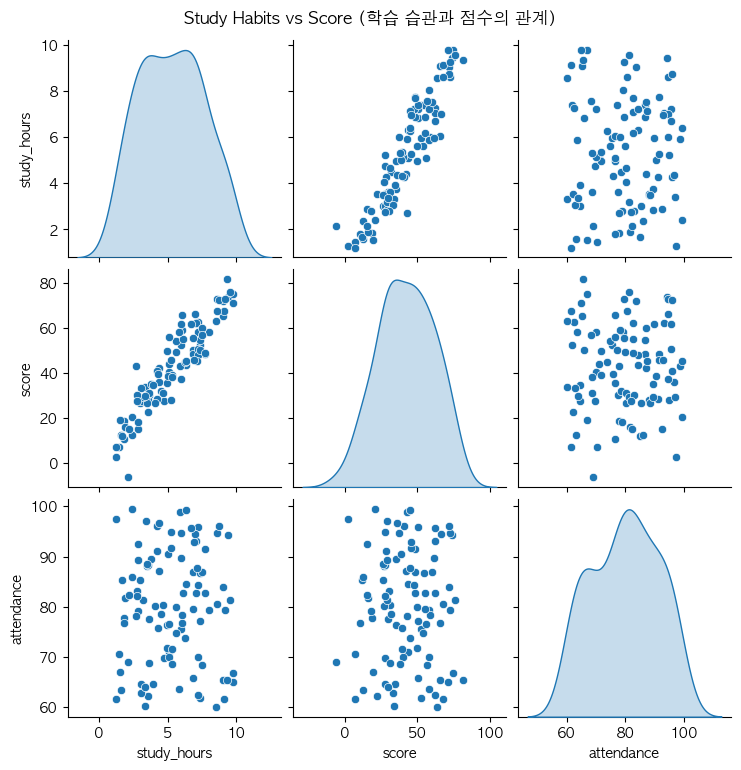

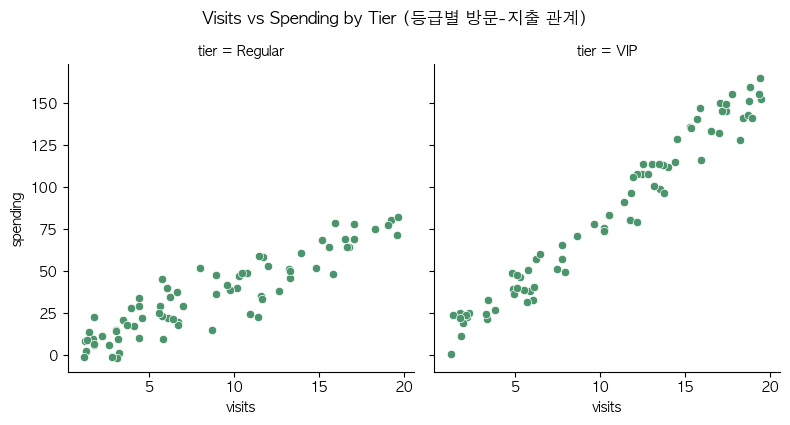

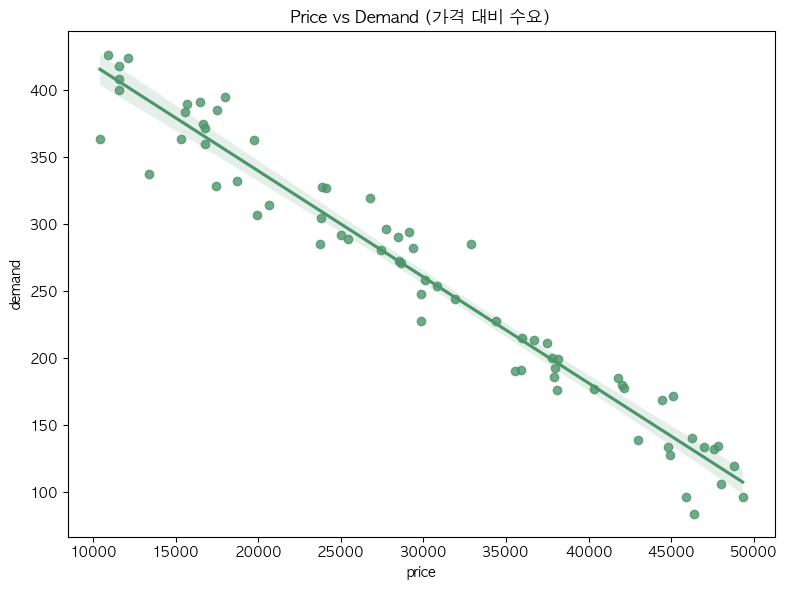

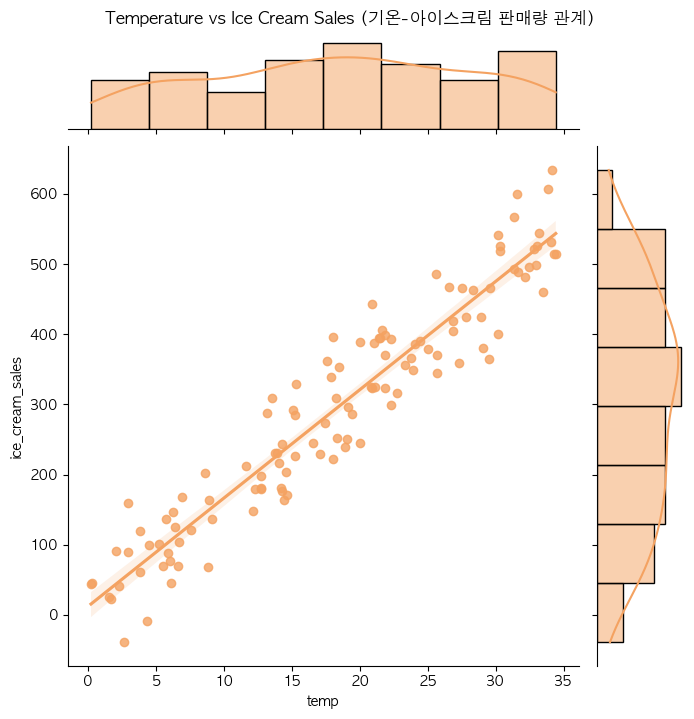

In [9]:
# ============================================================
# Practice -- fill in every ________ blank, then re-run the cell
# 연습 -- 아래 ________ 빈칸을 모두 채운 뒤 셀을 다시 실행하세요
# ============================================================
BLANK = "________"

def ready(*vals):
    return all(v != BLANK for v in vals)

# ---------- Part A: pairplot -- study habits ----------
np.random.seed(3)
n = 100
study_hours = np.random.uniform(1, 10, n)
score = study_hours * 8 + np.random.normal(0, 8, n)
attendance = np.random.uniform(60, 100, n)
df_a = pd.DataFrame({'study_hours': study_hours, 'score': score, 'attendance': attendance})

diag_a = "kde"   # TODO: which diag_kind draws smooth curves instead of histograms? ('kde')

if ready(diag_a):
    g = sns.pairplot(df_a, diag_kind=diag_a)
    g.figure.suptitle('Study Habits vs Score (학습 습관과 점수의 관계)', y=1.02)
    plt.show()
else:
    print("Part A \u270f\ufe0f  Fill in diag_a above, then re-run.")

# ---------- Part B: FacetGrid -- visits vs spending by tier ----------
np.random.seed(6)
n = 150
tiers_b = np.random.choice(['Regular', 'VIP'], n)
visits_b = np.random.uniform(1, 20, n)
spending_b = visits_b * np.where(tiers_b == 'VIP', 8, 4) + np.random.normal(0, 10, n)
df_b = pd.DataFrame({'tier': tiers_b, 'visits': visits_b, 'spending': spending_b})

facet_col_b  = "tier"   # TODO: which column should split the grid into panels?
chart_func_b = "scatterplot"   # TODO: sns function name (as a string) that draws points, e.g. 'scatterplot'

if ready(facet_col_b, chart_func_b):
    g = sns.FacetGrid(df_b, col=facet_col_b, height=4)
    g.map(getattr(sns, chart_func_b), 'visits', 'spending', color='#4C956C')
    g.figure.suptitle('Visits vs Spending by Tier (등급별 방문-지출 관계)', y=1.05)
    plt.show()
else:
    print("Part B \u270f\ufe0f  Fill in facet_col_b and chart_func_b above, then re-run.")

# ---------- Part C: regplot -- price vs demand ----------
np.random.seed(9)
price = np.random.uniform(10000, 50000, 70)
demand = 500 - price * 0.008 + np.random.normal(0, 20, 70)
df_c = pd.DataFrame({'price': price, 'demand': demand})

x_col_c = "price"   # TODO: which column is the input? ('price')
y_col_c = "demand"   # TODO: which column is the output? ('demand')

if ready(x_col_c, y_col_c):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.regplot(data=df_c, x=x_col_c, y=y_col_c, color='#4C956C', ax=ax)
    ax.set_title('Price vs Demand (가격 대비 수요)')
    plt.tight_layout()
    plt.show()
else:
    print("Part C \u270f\ufe0f  Fill in x_col_c and y_col_c above, then re-run.")

# ---------- Part D: jointplot -- temperature vs ice cream sales ----------
np.random.seed(4)
temp = np.random.uniform(0, 35, 120)
ice_cream_sales = temp * 15 + np.random.normal(0, 50, 120) + 20
df_d = pd.DataFrame({'temp': temp, 'ice_cream_sales': ice_cream_sales})

kind_d = "reg"   # TODO: which jointplot kind draws a scatter + regression line? ('reg')

if ready(kind_d):
    g = sns.jointplot(data=df_d, x='temp', y='ice_cream_sales', kind=kind_d, color='#F4A261', height=7)
    g.figure.suptitle('Temperature vs Ice Cream Sales (기온-아이스크림 판매량 관계)', y=1.02)
    plt.show()
else:
    print("Part D \u270f\ufe0f  Fill in kind_d above, then re-run.")

---
# ⚠️ Common Mistakes (자주 하는 실수)

### Mistake 1 — Trying to Pass `ax=` to a Figure-level Function (Figure-level 함수에 ax= 전달 시도)
`pairplot`, `FacetGrid`, and `jointplot` build their own Figure with multiple Axes internally, so `ax=` doesn't fit their design. `pairplot` raises a `TypeError`; `jointplot` accepts `ax=` but silently ignores it with a warning.  
pairplot, FacetGrid, jointplot은 내부적으로 여러 Axes를 가진 자체 Figure를 만들기 때문에 ax=가 애초에 맞지 않습니다. pairplot은 TypeError를 던지고, jointplot은 ax=를 받기는 하지만 경고와 함께 조용히 무시합니다.

✅ **Fix / 해결:** Use the object each function returns (`g.figure`) for figure-level title/save operations instead of pre-making an `ax`.

### Mistake 2 — Feeding Non-numeric Columns Straight into pairplot (범주형 컬럼을 그대로 pairplot에 넣기)
Categorical columns get forced into scatter axes as if they were numbers, or cause an error, when passed without being separated out via `hue=`.  
범주형 컬럼을 hue=로 분리하지 않고 그대로 넣으면 억지로 수치처럼 축에 표현되거나 에러가 발생합니다.

✅ **Fix / 해결:** Select only numeric columns for the grid (`df[['a','b','c']]`), and route categorical columns through `hue=`.

### Mistake 3 — Too Many Columns in pairplot (pairplot에 너무 많은 컬럼)
With 8+ numeric columns, the grid balloons to 64+ tiny panels that render slowly and are unreadable.  
수치형 컬럼이 8개 이상이면 격자가 64칸 이상으로 거대해져 렌더링이 느리고 읽기 어려워집니다.

✅ **Fix / 해결:** Pre-select the 3-6 most relevant columns before calling `pairplot`.

### Mistake 4 — FacetGrid with Many Categories and No `col_wrap` (범주가 많은데 col_wrap 미지정)
Without `col_wrap=`, every category gets its own column in a single row, running the layout off the edge of the screen.  
col_wrap=이 없으면 모든 범주가 한 줄에 나란히 배치되어 화면 밖으로 넘어갑니다.

✅ **Fix / 해결:** Set `col_wrap=2` (or similar) once you have more than about 4 categories.

### Mistake 5 — Reading a regplot Line as a Prediction Beyond the Data Range (관측 범위 밖까지 회귀선을 예측으로 오해)
The regression line only summarizes the relationship *within* the observed x-range; mentally extending it past the data (extrapolation) isn't statistically justified.  
회귀선은 관측된 x 범위 *안에서*의 관계를 요약할 뿐이며, 데이터 범위를 벗어난 값까지 마음속으로 연장하는 것(외삽)은 통계적으로 정당화되지 않습니다.

✅ **Fix / 해결:** Treat the line as valid only inside the plotted x-range; any extrapolation needs separate validation.

### Mistake 6 — Missing a Bimodal Marginal Histogram in jointplot (jointplot의 이중 봉우리 히스토그램 놓치기)
It's easy to look only at the central scatter and miss that the top/side histograms have two peaks — a sign the data is really two sub-populations, not one.  
중앙 산점도만 보고 위·옆의 히스토그램이 두 개의 봉우리를 가진다는 사실을 놓치기 쉽습니다 — 이는 데이터가 사실 하나가 아니라 두 개의 하위 집단이라는 신호입니다.

✅ **Fix / 해결:** Always check the marginal histograms' shape, not just the central scatter, before concluding there's a single trend.

---
# 💡 Tips (팁)
Useful tips or shortcuts / 유용한 팁과 단축법

- `pairplot`'s `hue=` colors ALL panels at once — a fast way to see if a relationship differs by group, not just whether it exists.<br>pairplot의 hue=는 모든 칸을 한 번에 색칠합니다 -- 관계가 존재하는지뿐 아니라 그룹마다 다른지도 빠르게 볼 수 있습니다.
- `FacetGrid.map()` isn't limited to `scatterplot` — pass `sns.regplot` for a trend line per panel, or `sns.histplot` for a distribution per panel.<br>FacetGrid의 .map()은 scatterplot에 국한되지 않습니다 -- sns.regplot을 넘기면 칸마다 추세선을, sns.histplot을 넘기면 칸마다 분포를 그릴 수 있습니다.
- `order=2` in `regplot` isn't "better" by default — always compare `order=1` vs `order=2` side by side before deciding a relationship is curved.<br>regplot의 order=2가 기본적으로 "더 낫다"는 것은 아닙니다 -- 관계가 곡선이라고 결론 내리기 전에 항상 order=1과 order=2를 나란히 비교하세요.
- `corr.where(~np.eye(len(corr), dtype=bool))` is a reusable trick for finding the strongest off-diagonal correlation in any correlation matrix.<br>corr.where(~np.eye(len(corr), dtype=bool))는 어떤 상관관계 행렬에서든 대각선을 제외한 가장 강한 상관관계를 찾는 재사용 가능한 트릭입니다.
- `jointplot`'s `kind='hex'` is the fix once your scatter has so many points it turns into a solid blob.<br>산점도의 점이 너무 많아 하나의 덩어리처럼 보인다면 jointplot의 kind='hex'가 해결책입니다.

---
# 🔗 Related Concepts (관련 개념)

```
Seaborn Basics (Section 10)
   countplot / barplot / lineplot / heatmap   [Axes-level]
        ↓
Seaborn Advanced (Section 11)  ← you are here / 현재 위치
   pairplot / FacetGrid / jointplot           [Figure-level]
   regplot                                    [Axes-level]
        ↓
Styling & Export (Section 12)
        ↓
Plotly (Sections 13-14)
        ↓
Tableau Public (Sections 15-17)
```

*How is today's topic connected to other concepts?*

**EN:** Section 10 was entirely Axes-level functions, so `ax=` always worked without exception. Today introduces the first Figure-level functions — the same split reappears in Section 14, where Plotly's `go.Figure` (Axes-level style, you assemble it) contrasts with Plotly Express shortcuts that build a whole figure at once. Recognizing "does this function build its own canvas, or do I hand it one?" is a pattern that recurs across every library in this curriculum.

**KR:** 섹션 10은 전부 Axes-level 함수였기 때문에 ax=가 예외 없이 항상 통했습니다. 오늘은 처음으로 Figure-level 함수를 소개하는데, 이는 섹션 14에서 다시 보게 될 구분과 같습니다: Plotly의 go.Figure(직접 조립하는 Axes-level 스타일)과 한 번에 전체 Figure를 만드는 Plotly Express 단축 함수. "이 함수가 스스로 캔버스를 만드는가, 아니면 내가 캔버스를 건네주는가?"를 구분하는 감각은 이 커리큘럼의 모든 라이브러리에서 반복되는 패턴입니다.

---
# 💼 Business Example (비즈니스 예시)
*How would a Business Analyst use this?*

**Scenario / 시나리오:**

**EN:** Your VP wants ONE slide before the quarterly review that answers: does customer engagement (visit count) actually predict spending, and is that relationship the same for new and returning customers?

**KR:** 부사장님이 분기 리뷰 전에 한 장의 슬라이드로 답을 원합니다: 고객 참여도(방문 횟수)가 실제로 지출을 예측하는가, 그리고 그 관계는 신규 고객과 기존 고객이 같은가?

**To-do / 할 일:**
- [x] Plot engagement vs spending with a regression line and confidence band using `regplot`<br>regplot으로 참여도-지출 관계를 회귀선과 신뢰구간과 함께 그리기
- [x] Split the same relationship by customer type with `FacetGrid` to check if it holds for both groups<br>FacetGrid로 고객 유형별로 같은 관계를 나누어 두 그룹 모두에서 성립하는지 확인하기
- [x] Quantify the relationship strength (correlation) for each group separately<br>각 그룹별로 관계의 강도(상관계수)를 따로 정량화하기
- [x] Write one recommendation sentence for the VP<br>부사장님을 위한 한 문장 제안 작성하기

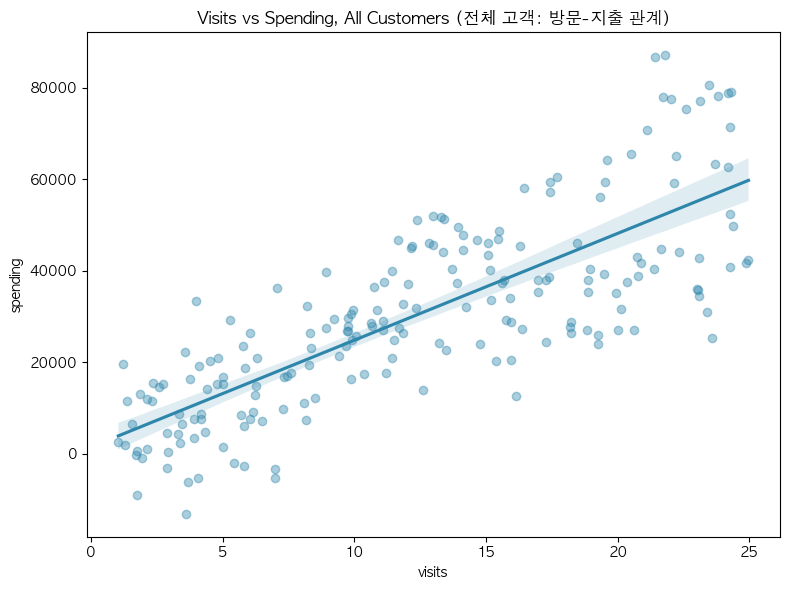

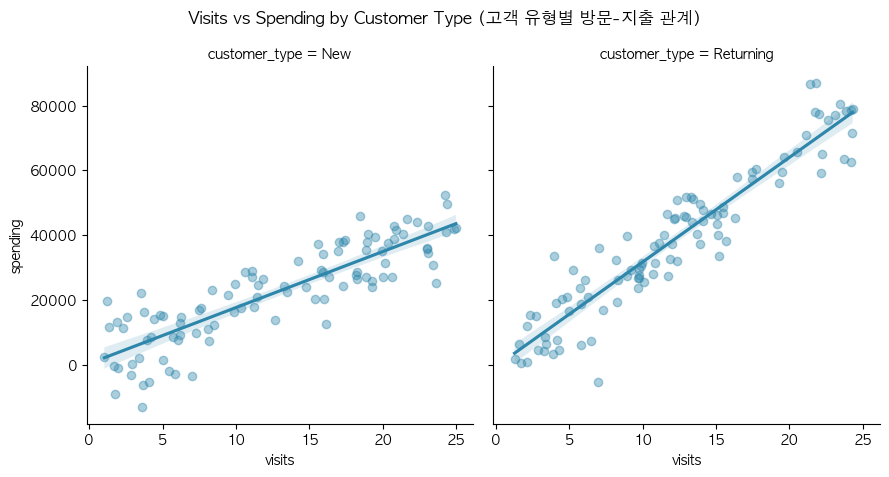

New: correlation = 0.86
New (신규): 상관계수 = 0.86
Returning: correlation = 0.94
Returning (기존): 상관계수 = 0.94
Recommendation: engagement predicts spending in both groups, but the payoff per visit is much
higher for returning customers -- retention campaigns likely have better ROI than pure acquisition.
제안: 참여도는 두 그룹 모두에서 지출을 예측하지만, 방문당 효과는 기존 고객에서 훨씬 큽니다 --
리텐션 캠페인이 순수 신규 획득보다 ROI가 높을 가능성이 있습니다.


In [8]:
np.random.seed(15)
customer_type = ['New', 'Returning'] * 100
visits = np.random.uniform(1, 25, 200)
slopes = {'New': 1800, 'Returning': 3200}
spending = [visits[i] * slopes[customer_type[i]] + np.random.normal(0, 8000) for i in range(200)]
df = pd.DataFrame({'customer_type': customer_type, 'visits': visits, 'spending': spending})

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df, x='visits', y='spending', color='#2E86AB', ax=ax, scatter_kws={'alpha': 0.4})
ax.set_title('Visits vs Spending, All Customers (전체 고객: 방문-지출 관계)')
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df, col='customer_type', height=4.5, col_order=['New', 'Returning'])
g.map(sns.regplot, 'visits', 'spending', color='#2E86AB', scatter_kws={'alpha': 0.4})
g.figure.suptitle('Visits vs Spending by Customer Type (고객 유형별 방문-지출 관계)', y=1.05)
plt.show()

for ctype in ['New', 'Returning']:
    sub = df[df['customer_type'] == ctype]
    corr = sub['visits'].corr(sub['spending'])
    ctype_kr = '신규' if ctype == 'New' else '기존'
    print(f"{ctype}: correlation = {corr:.2f}")
    print(f"{ctype} ({ctype_kr}): 상관계수 = {corr:.2f}")

print("Recommendation: engagement predicts spending in both groups, but the payoff per visit is much")
print("higher for returning customers -- retention campaigns likely have better ROI than pure acquisition.")
print("제안: 참여도는 두 그룹 모두에서 지출을 예측하지만, 방문당 효과는 기존 고객에서 훨씬 큽니다 --")
print("리텐션 캠페인이 순수 신규 획득보다 ROI가 높을 가능성이 있습니다.")

---
# 📝 Summary (요약)
*Write today's concept in 3~5 sentences.*

**EN:** This section covered a second family of Seaborn tools built for exploring relationships rather than summarizing single categories. `pairplot` scans every pair of numeric columns at once for a fast EDA overview; `FacetGrid` repeats any chart type once per category so you can compare groups side by side; `regplot` adds a statistically grounded trend line and confidence band to a scatter plot; `jointplot` combines a relationship view with each variable's own distribution in one figure. The critical distinction to carry forward is Figure-level vs. Axes-level: `pairplot`, `FacetGrid`, and `jointplot` build their own Figure and refuse `ax=`, while `regplot` behaves like everything from Section 10 and slots into a layout you control.

**KR:** 이번 섹션은 하나의 범주를 요약하기보다 관계를 탐색하기 위한 Seaborn 도구 두 번째 그룹을 다뤘습니다. pairplot은 모든 수치형 컬럼 쌍을 한 번에 훑어 빠른 EDA 개요를 제공하고, FacetGrid는 어떤 차트든 범주마다 반복해서 그려 그룹을 나란히 비교할 수 있게 하며, regplot은 산점도에 통계적으로 근거 있는 추세선과 신뢰구간을 더하고, jointplot은 관계와 각 변수 자신의 분포를 하나의 그림으로 결합합니다. 앞으로 계속 기억해야 할 핵심 구분은 Figure-level 대 Axes-level입니다: pairplot, FacetGrid, jointplot은 자체 Figure를 만들고 ax=를 거부하는 반면, regplot은 섹션 10의 모든 함수처럼 동작하며 직접 제어하는 레이아웃에 끼워 넣을 수 있습니다.

---
# 📌 One Sentence Summary (한 문장 요약)
Today's topic in ONE sentence. / 오늘의 주제를 한 문장으로.

> **EN:** `pairplot`, `FacetGrid`, and `jointplot` are Figure-level tools that explore relationships across many variables or groups at once by building their own multi-panel Figure, while `regplot` is an Axes-level tool that adds a statistically grounded trend line to a single relationship you control.

> **KR:** pairplot, FacetGrid, jointplot은 자체적으로 여러 패널의 Figure를 만들어 여러 변수·그룹에 걸친 관계를 한 번에 탐색하는 Figure-level 도구이며, regplot은 직접 제어하는 하나의 관계에 통계적으로 근거 있는 추세선을 더하는 Axes-level 도구입니다.

---
# ❓ Review Questions (복습 질문)

**Q1 (EN).** Why does `sns.pairplot(df, ax=ax)` raise a `TypeError`, and what should you use instead to set a title on the whole grid?
**Q1 (KR).** `sns.pairplot(df, ax=ax)`가 TypeError를 던지는 이유는 무엇이며, 전체 격자에 제목을 달려면 무엇을 대신 사용해야 하나요?

pairplot is Figure-level, so ax= raises TypeError. Title the whole grid with g.figure.suptitle().  
스스로 Figure를 만들므로 ax=가 안 됩니다. 전체 제목은 g.figure.suptitle()입니다.

**Q2 (EN).** What does `col_wrap=` do in `FacetGrid`, and when do you need it?
**Q2 (KR).** FacetGrid에서 col_wrap=은 무엇을 하며, 언제 필요한가요?

col_wrap wraps facet columns onto the next row when there are too many categories.  
범주가 많을 때 한 줄에 다 놓지 말고 다음 줄로 넘깁니다.

**Q3 (EN).** What's the difference between `regplot`'s `order=1` and `order=2`, and how would you decide which one fits your data better?
**Q3 (KR).** regplot의 order=1과 order=2의 차이는 무엇이며, 데이터에 어떤 것이 더 맞는지 어떻게 판단하나요?

order=1 is a straight line; order=2 is a curve. Compare them side by side to see which follows the points.  
1은 직선, 2는 곡선. 점 위에 어느 선이 더 붙는지 비교하세요.

**Q4 (EN).** In a `jointplot`, what does it mean if the marginal histogram on top has two separate peaks?
**Q4 (KR).** jointplot에서 위쪽 주변 히스토그램에 두 개의 분리된 봉우리가 있다면 무엇을 의미하나요?

Two peaks on the top histogram mean the x-variable is bimodal — two sub-populations, not one trend.  
위쪽 히스토그램이 쌍봉이면 x에 하위 집단이 둘입니다.

**Q5 (EN).** Which of the four functions in this section are Figure-level, and which is Axes-level? How can you tell just from whether they accept `ax=`?
**Q5 (KR).** 이 섹션의 네 함수 중 어느 것이 Figure-level이고 어느 것이 Axes-level인가요? ax=를 받는지 여부만으로 어떻게 구분할 수 있나요?

If it accepts ax=, it is Axes-level (regplot). If not, Figure-level (pairplot, FacetGrid, jointplot).  
ax= 되면 Axes-level, 안 되면 Figure-level입니다.

---
*📅 Try answering these again in a few days. / 며칠 후 다시 답해보세요.*